## Visualizations

Settings and seeds are discovered directly from wandb run display names: each resumed phase is logged to wandb under its own exact display name (e.g. `constrained_mean_seed100_rd1-3`), which is parsed as `'{condition}_seed{seed}_rd{start}-{end}'`. Due to HPC wall-time limits, the number of phases and their round ranges differ per condition/seed and aren't assumed here — they're discovered from whatever matching runs exist in the wandb project. Phases are ordered by the round number parsed from the name and stitched into one continuous per-seed timeline.

In [1]:
import math
import numpy as np
import pandas as pd
import wandb
import matplotlib.pyplot as plt

In [2]:
# the variable we need:
"""
(train acc + ppl) vs n_steps
(val acc *4 + ppl *4) vs n_steps
lambda mean vs n_steps

(val acc *4 + ppl *4) vs n_tokens
"""

'\n(train acc + ppl) vs n_steps\n(val acc *4 + ppl *4) vs n_steps\nlambda mean vs n_steps\n\n(val acc *4 + ppl *4) vs n_tokens\n'

In [15]:
import re

ENTITY_PROJECT = "tecchk-cyt-duke-university/amplify_ally"
N_STEPS_PER_ROUND = 8000  # strategy.n_steps, same across all runs/conditions
# SEEDS = [100, 300, 500]  # seed suffix on each condition's run names
SEEDS = [500]

CONDITION_LABELS = {
    "unconstrained": "Unconstrained",
    "constrained_swe": "Constrained + SWE pooling",
    "constrained_mean": "Constrained + mean pooling",
}

# Fixed color per known condition (categorical slots 1-3), assigned once so a
# condition's color never changes across cells/plots. Any newly discovered
# condition not in this dict falls back to gray at plot time.
CONDITION_COLORS = {
    "unconstrained": "#eda100",     # yellow
    "constrained_swe": "#1baf7a",   # aqua
    "constrained_mean": "#2a78d6",  # blue
}

api = wandb.Api()

RUN_NAME_RE = re.compile(r"^(?P<condition>.+)_seed(?P<seed>\d+)_rd(?P<start>\d+)-(?P<end>\d+)$")


def discover_run_groups(entity_project: str = ENTITY_PROJECT, seeds: list = SEEDS):
    """Discover conditions/phases straight from wandb run display names.

    Each resumed phase is logged to wandb under a display name of the form
    '{condition}_seed{seed}_rd{start}-{end}' (seed in `seeds`); runs whose name
    doesn't match this pattern, or whose seed isn't in `seeds`, are skipped.
    The number of phases per condition/seed is arbitrary and read straight off
    whatever runs exist, not hardcoded.

    Returns run_groups[condition][seed_label] -> list of phase dicts
    {"start", "end", "name", "n_steps", "run"}, sorted by start round. "n_steps"
    is N_STEPS_PER_ROUND (steps per round), needed to know where each phase's
    round boundary falls in num_steps. "run" is the wandb Run object itself,
    fetched once here rather than re-queried by name later.
    """
    run_groups: dict = {}
    seen_names: dict = {}

    for run in api.runs(entity_project):
        m = RUN_NAME_RE.match(run.name)
        if not m:
            continue
        seed = int(m.group("seed"))
        if seed not in seeds:
            continue

        if run.name in seen_names:
            raise ValueError(f"{run.name}: multiple wandb runs found, expected exactly 1")
        seen_names[run.name] = run

        condition = m.group("condition")
        phase = {
            "start": int(m.group("start")),
            "end": int(m.group("end")),
            "name": run.name,
            "n_steps": N_STEPS_PER_ROUND,
            "run": run,
        }
        run_groups.setdefault(condition, {}).setdefault(f"seed_{seed}", []).append(phase)

    for seed_phases in run_groups.values():
        for phases in seed_phases.values():
            phases.sort(key=lambda p: p["start"])

    return run_groups


run_groups = discover_run_groups()
for condition, seeds in run_groups.items():
    for seed_label, phases in seeds.items():
        print(f"{condition}/{seed_label}: {[p['name'] for p in phases]}")

unconstrained/seed_500: ['unconstrained_seed500_rd1-5', 'unconstrained_seed500_rd6-10']
constrained_mean/seed_500: ['constrained_mean_seed500_rd1-3', 'constrained_mean_seed500_rd7-10']


In [16]:

CUMULATIVE_COLS_THAT_RESET_ON_RESUME = ["num_tokens", "num_samples", "num_masked_tokens"]


def stitch_histories(histories: dict, order: list[str]):
    """Concatenate one seed's chronological run segments into a continuous timeline."""
    stitched_parts = []
    offsets = {col: 0 for col in CUMULATIVE_COLS_THAT_RESET_ON_RESUME}

    for label in order:
        df = histories[label].copy()
        for col in CUMULATIVE_COLS_THAT_RESET_ON_RESUME:
            if col in df.columns:
                df[col] = df[col] + offsets[col]

        stitched_parts.append(df)
        for col in CUMULATIVE_COLS_THAT_RESET_ON_RESUME:
            if col in df.columns and df[col].notna().any():
                offsets[col] = df[col].max()

    combined = pd.concat(stitched_parts, ignore_index=True)
    combined = combined.sort_values("num_steps").drop_duplicates(subset="num_steps", keep="last")
    return combined.reset_index(drop=True)

In [17]:
def get_condition_stitched(run_groups: dict):
    """For every condition/seed, use the phase runs discovered from wandb run
    names (already in rd-start order) and resume-stitch them into one
    continuous timeline.

    Returns condition_stitched[condition][seed_label] -> stitched DataFrame
    """
    condition_stitched = {}

    for condition, seeds in run_groups.items():
        condition_stitched[condition] = {}
        for seed_label, phases in seeds.items():
            seg_histories = {}
            for i, phase in enumerate(phases):
                df = phase["run"].history(samples=1_000_000, pandas=True)
                if i < len(phases) - 1 and "num_steps" in df.columns:
                    boundary = phase["end"] * phase["n_steps"]
                    df = df[df["num_steps"] <= boundary]
                seg_histories[f"seg{i}"] = df

            seg_order = list(seg_histories.keys())
            stitched_df = stitch_histories(seg_histories, seg_order)
            condition_stitched[condition][seed_label] = stitched_df
            print(f"{condition}/{seed_label} {[p['name'] for p in phases]}: {stitched_df.shape}")

    return condition_stitched


condition_stitched = get_condition_stitched(run_groups)

unconstrained/seed_500 ['unconstrained_seed500_rd1-5', 'unconstrained_seed500_rd6-10']: (80001, 28)
constrained_mean/seed_500 ['constrained_mean_seed500_rd1-3', 'constrained_mean_seed500_rd7-10']: (71011, 28)


In [18]:
def average_seed_dfs_by_step(dfs: list, x_key: str, y_key: str):
    """Exact-align on x_key (seeds share the same step grid) and average across seeds."""
    series_list = []
    for df in dfs:
        if x_key not in df.columns or y_key not in df.columns:
            continue
        s = df[[x_key, y_key]].dropna().drop_duplicates(subset=x_key).set_index(x_key)[y_key]
        series_list.append(s)
    if not series_list:
        return pd.DataFrame(columns=[x_key, "mean", "std", "n"])
    combined = pd.concat(series_list, axis=1)
    combined.index.name = None  # avoid clash with the x_key column built from this index below
    return pd.DataFrame({
        x_key: combined.index,
        "mean": combined.mean(axis=1, skipna=True),
        "std": combined.std(axis=1, skipna=True),
        "n": combined.count(axis=1),
    }).sort_values(x_key).reset_index(drop=True)


In [19]:
def plot_condition_comparison(ax, condition_stitched, x_key, y_key, colors, labels=None, title=None):
    """Mean +/- std across seeds, one line+band per condition, all on one axis."""
    for condition, seed_dfs in condition_stitched.items():
        avg = average_seed_dfs_by_step(list(seed_dfs.values()), x_key, y_key)
        if avg.empty:
            continue
        color = colors.get(condition, "#999999")
        ax.plot(avg[x_key], avg["mean"], color=color, linewidth=1.2,
                 label=(labels or {}).get(condition, condition))
        ax.fill_between(avg[x_key], avg["mean"] - avg["std"], avg["mean"] + avg["std"],
                         color=color, alpha=0.15, linewidth=0)
    ax.set_title(title or y_key)
    ax.set_xlabel(x_key)
    ax.set_ylabel(y_key)
    ax.grid(True, color="#e1e0d9", linewidth=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8)


def plot_metric_group(condition_stitched, x_key, y_keys, colors, labels=None,
                       titles=None, ncols=4, panel_size=(4.5, 3.2)):
    """One subplot per y_key sharing the same x variable (never a dual-axis overlay)."""
    n = len(y_keys)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel_size[0] * ncols, panel_size[1] * nrows), squeeze=False)
    axes = axes.flatten()
    for ax, y_key in zip(axes, y_keys):
        title = (titles or {}).get(y_key)
        plot_condition_comparison(ax, condition_stitched, x_key, y_key, colors, labels, title)
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.tight_layout()
    return fig, axes

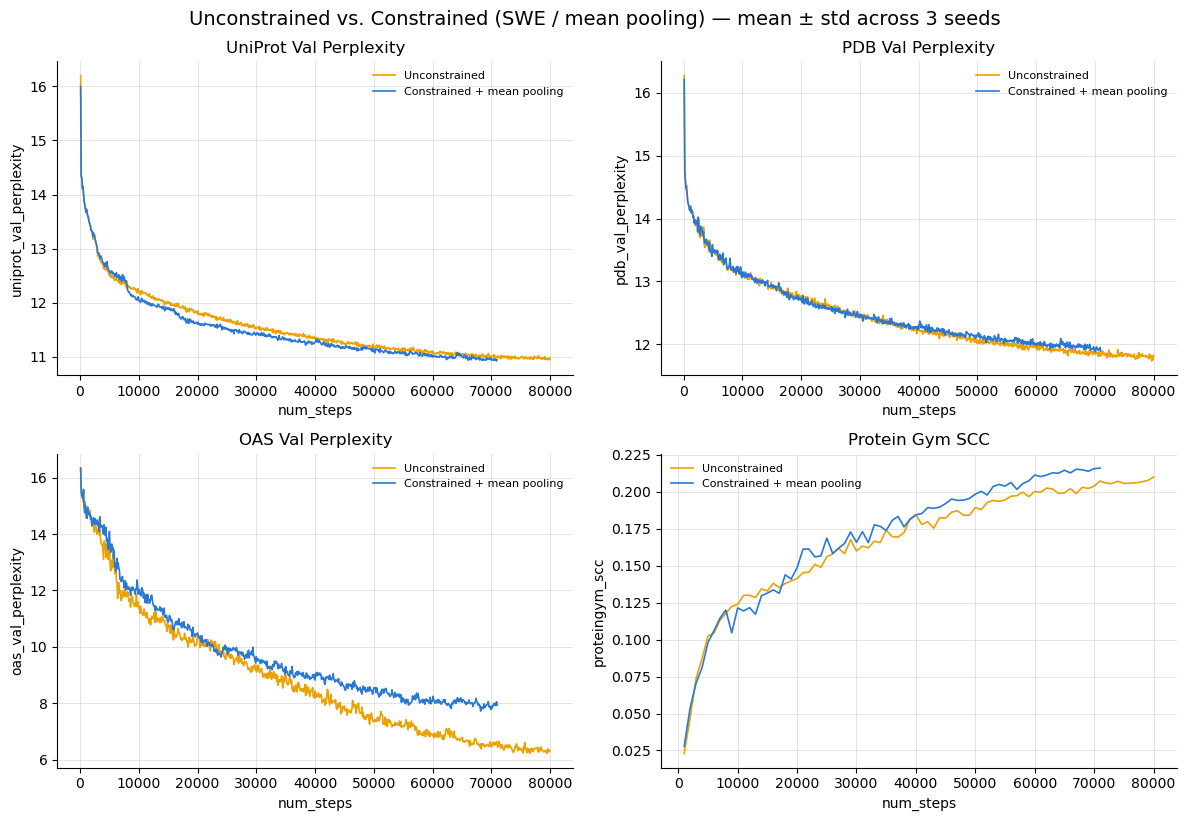

In [20]:
titles = {
    "uniprot_val_perplexity": "UniProt Val Perplexity",
    "pdb_val_perplexity":     "PDB Val Perplexity",
    "oas_val_perplexity":     "OAS Val Perplexity",
    "proteingym_scc":         "Protein Gym SCC",
}

fig, axes = plot_metric_group(
    condition_stitched, x_key="num_steps", y_keys=list(titles.keys()),
    colors=CONDITION_COLORS, labels=CONDITION_LABELS, titles=titles,
    ncols=2, panel_size=(6, 4),
)
fig.suptitle("Unconstrained vs. Constrained (SWE / mean pooling) — mean ± std across 3 seeds", fontsize=14, y=1.02)
plt.show()